# Analiza dataset-ului Titanic

În acest notebook realizăm o analiză exploratorie a dataset-ului Titanic
folosind Pandas, Seaborn și Matplotlib.

Scopul analizei este să observăm cum influențează:
- sexul
- clasa biletului

șansele de supraviețuire ale pasagerilor.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
titanic = sns.load_dataset("titanic")

print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
print("Dimensiunea datasetului:")
print(titanic.shape)

print("\nTipurile de date:")
print(titanic.dtypes)

print("\nValori lipsă:")
print(titanic.isnull().sum())

Dimensiunea datasetului:
(891, 15)

Tipurile de date:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Valori lipsă:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
print("Rata globală de supraviețuire:")
print(titanic["survived"].mean())

Rata globală de supraviețuire:
0.3838383838383838


In [5]:
rata_sex = titanic.groupby("sex")["survived"].mean()

print("Rata de supraviețuire per sex:")
print(rata_sex)

Rata de supraviețuire per sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [6]:
rata_clasa = titanic.groupby("class")["survived"].mean()

print("Rata de supraviețuire per clasă:")
print(rata_clasa)

Rata de supraviețuire per clasă:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


/tmp/ipykernel_487/3813761624.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_clasa = titanic.groupby("class")["survived"].mean()


In [7]:
pivot = titanic.pivot_table(
    values="survived",
    index="class",
    columns="sex",
    aggfunc="mean"
)

print(pivot)

sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447


/tmp/ipykernel_487/225882315.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = titanic.pivot_table(


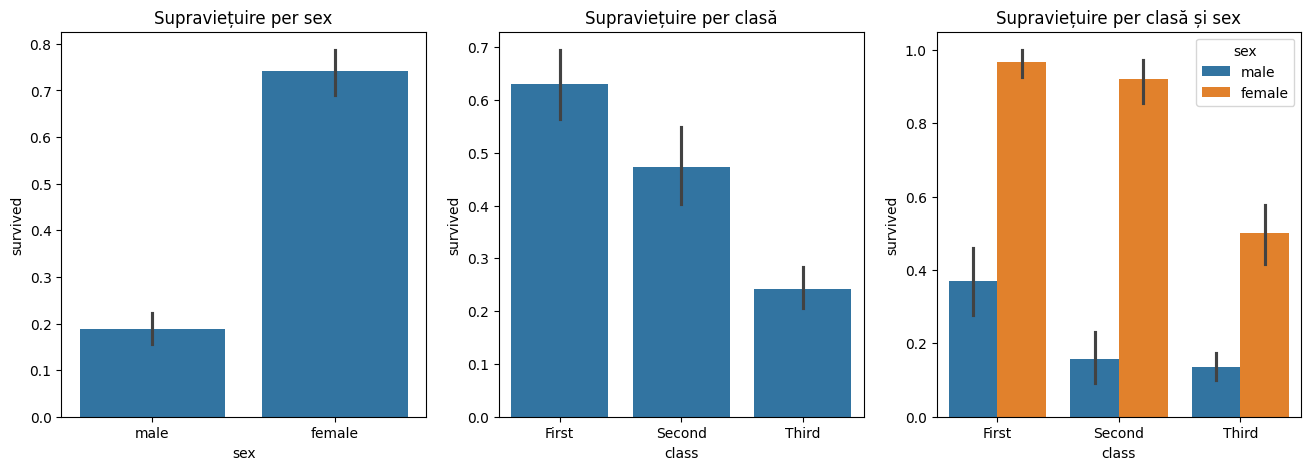

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(data=titanic, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Supraviețuire per sex")

sns.barplot(data=titanic, x="class", y="survived", ax=axes[1])
axes[1].set_title("Supraviețuire per clasă")

sns.barplot(data=titanic, x="class", y="survived", hue="sex", ax=axes[2])
axes[2].set_title("Supraviețuire per clasă și sex")

plt.show()

## Concluzie

Analiza arată că sexul și clasa socială au influențat puternic șansele
de supraviețuire.

Femeile au avut o rată de supraviețuire mult mai mare decât bărbații,
probabil datorită regulii "femeile și copiii primii".

De asemenea, pasagerii din clasa I au avut șanse mai mari de supraviețuire
comparativ cu cei din clasele inferioare.